In [ ]:
# NBA Player Trajectory Modeling
# Preprocessing & Feature Engineering

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Load and Drop Junk Column

df = pd.read_csv('all_seasons.csv')
print(f"Raw shape: {df.shape}")

df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Shape after column drop: {df.shape}")
print("Columns:", list(df.columns))

Raw shape: (12844, 22)
Shape after column drop: (12844, 21)
Columns: ['player_name', 'team_abbreviation', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season']


In [ ]:
# Draft Column Cleaning
# draft_round contains: '1', '2', 'Undrafted', and junk values '3','4','6','7','8','0'
# Keep only valid values, junk rows (around 50 total) are data artifacts and dropped
# Encoding: Undrafted=0, Round 1=1, Round 2=2

VALID_ROUNDS = {'1', '2', 'Undrafted'}

junk_mask = ~df['draft_round'].isin(VALID_ROUNDS)
print(f"\nJunk draft_round rows dropped: {junk_mask.sum()}")

df = df[~junk_mask].copy().reset_index(drop=True)

df['draft_round'] = df['draft_round'].map({'Undrafted': 0, '1': 1, '2': 2}).astype(int)
df['draft_number'] = pd.to_numeric(df['draft_number'], errors='coerce').fillna(0).astype(int)

print("Draft round distribution after cleaning:")
print(df['draft_round'].value_counts())


Junk draft_round rows dropped: 50
Draft round distribution after cleaning:
draft_round
1    7351
2    3032
0    2411
Name: count, dtype: int64


In [ ]:
# Handle Nulls

df['college'] = df['college'].fillna('International')

print("\nNull counts after cleaning (all should be 0):")
print(df.isnull().sum())


Null counts after cleaning (all should be 0):
player_name          0
team_abbreviation    0
age                  0
player_height        0
player_weight        0
college              0
country              0
draft_year           0
draft_round          0
draft_number         0
gp                   0
pts                  0
reb                  0
ast                  0
net_rating           0
oreb_pct             0
dreb_pct             0
usg_pct              0
ts_pct               0
ast_pct              0
season               0
dtype: int64


In [ ]:
# Clip Extreme Net_Rating Outliers
# Players with 1-5 games produce extreme net_ratings
# These are statistical noise that destroy clustering
# This range covers all realistic full season NBA net ratings comfortably.

print(f"\nNet rating before clip — min: {df['net_rating'].min()}, max: {df['net_rating'].max()}")
df['net_rating'] = df['net_rating'].clip(lower=-30, upper=30)
print(f"Net rating after clip  — min: {df['net_rating'].min()}, max: {df['net_rating'].max()}")


Net rating before clip — min: -250.0, max: 300.0
Net rating after clip  — min: -30.0, max: 30.0


In [ ]:
# Resolve Traded Players
# We merge them into one combined row using a games played weighted average

numeric_stats = ['pts', 'reb', 'ast', 'net_rating',
                 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']

def weighted_avg_merge(group):
    """Combine a traded player's two team-rows into one weighted-average row."""
    if len(group) == 1:
        return group.iloc[0]
    total_gp = group['gp'].sum()
    row = group.iloc[0].copy()
    row['gp'] = total_gp
    row['team_abbreviation'] = 'TOT'
    for col in numeric_stats:
        row[col] = (group[col] * group['gp']).sum() / total_gp
    return row

df = (df.groupby(['player_name', 'season'], as_index=False)
        .apply(weighted_avg_merge)
        .reset_index(drop=True))

print(f"\nShape after resolving traded players: {df.shape}")


Shape after resolving traded players: (12790, 21)


In [ ]:
# Engineer Career Year
# Sort each player's seasons chronologically and number them
# career_year is the backbone of trajectory modeling.

df['season_start'] = df['season'].str[:4].astype(int)
df = df.sort_values(['player_name', 'season_start']).reset_index(drop=True)
df['career_year'] = df.groupby('player_name').cumcount() + 1

# Check
print("\nCareer year check — LeBron James:")
print(df[df['player_name'] == 'LeBron James']
      [['season', 'career_year', 'age', 'pts']].to_string())


Career year check — LeBron James:
       season  career_year   age   pts
7696  2003-04            1  19.0  20.9
7697  2004-05            2  20.0  27.2
7698  2005-06            3  21.0  31.4
7699  2006-07            4  22.0  27.3
7700  2007-08            5  23.0  30.0
7701  2008-09            6  24.0  28.4
7702  2009-10            7  25.0  29.7
7703  2010-11            8  26.0  26.7
7704  2011-12            9  27.0  27.1
7705  2012-13           10  28.0  26.8
7706  2013-14           11  29.0  27.1
7707  2014-15           12  30.0  25.3
7708  2015-16           13  31.0  25.3
7709  2016-17           14  32.0  26.4
7710  2017-18           15  33.0  27.5
7711  2018-19           16  34.0  27.4
7712  2019-20           17  35.0  25.3
7713  2020-21           18  36.0  25.0
7714  2021-22           19  37.0  30.3
7715  2022-23           20  38.0  28.9


In [ ]:
# Keep players with 3+ Seasons
# Players with fewer than 3 seasons have no career arc to model

seasons_per_player = df.groupby('player_name')['career_year'].max()
qualified_players  = seasons_per_player[seasons_per_player >= 3].index
df = df[df['player_name'].isin(qualified_players)].copy().reset_index(drop=True)

print(f"\nShape after 3+ season filter: {df.shape}")
print(f"Unique players remaining: {df['player_name'].nunique()}")


Shape after 3+ season filter: (11410, 23)
Unique players remaining: 1557


In [ ]:
# Composite Performance Score
# A single number representing how good a player's season was relative to the entire league
# composite_score > 0  means above-average season
# composite_score < 0  means below-average season

perf_cols = ['pts', 'net_rating', 'ts_pct', 'usg_pct']

scaler_perf = StandardScaler()
df_perf_z   = pd.DataFrame(
    scaler_perf.fit_transform(df[perf_cols]),
    columns=[f'{c}_z' for c in perf_cols]
)
df['composite_score'] = df_perf_z.mean(axis=1)

print("\nComposite score stats:")
print(df['composite_score'].describe().round(3))


Composite score stats:
count    11410.000
mean         0.000
std          0.690
min         -3.677
25%         -0.401
50%         -0.021
75%          0.388
max          5.102
Name: composite_score, dtype: float64


In [ ]:
# Targer_Variable is_peak
# Flagging seasons as peak seasons
# Player-relative threshold: a bench player's best years are still flagged, even if their absolute numbers are low.
# is_peak = 1  peak season
# is_peak = 0  non-peak season

threshold_map        = df.groupby('player_name')['composite_score'].quantile(0.67)
df['peak_threshold'] = df['player_name'].map(threshold_map)
df['is_peak']        = (df['composite_score'] >= df['peak_threshold']).astype(int)
df.drop(columns=['peak_threshold'], inplace=True)

print("\nPeak season distribution:")
print(df['is_peak'].value_counts())
print(f"Overall peak rate: {df['is_peak'].mean():.1%}")


Peak season distribution:
is_peak
0    7639
1    3771
Name: count, dtype: int64
Overall peak rate: 33.0%


In [ ]:
# Player level trajectory features (for clustering)
# Summarize each player's entire career into one feature vector.
# These player level features are what K-Means will cluster on.
#   peak_age         - age at their best season
#   career_length    - total seasons played (3+)
#   avg_score        - mean composite_score across career
#   score_slope      - linear trend: positive = rising, negative = declining
#   peak_career_year - which year of their career was their best
#   draft_round      - 0=undrafted, 1=R1, 2=R2
#   player_height    - physical attribute

def career_slope(grp):
    """Fit a linear trend to composite_score vs career_year."""
    if len(grp) < 2:
        return 0.0
    return np.polyfit(grp['career_year'].values, grp['composite_score'].values, 1)[0]

records = []
for pname, grp in df.groupby('player_name'):
    best_idx = grp['composite_score'].idxmax()
    records.append({
        'player_name':       pname,
        'peak_age':          grp.loc[best_idx, 'age'],
        'career_length':     grp['career_year'].max(),
        'avg_score':         grp['composite_score'].mean(),
        'score_slope':       career_slope(grp),
        'peak_career_year':  grp.loc[best_idx, 'career_year'],
        'draft_round':       grp['draft_round'].iloc[0],
        'player_height':     grp['player_height'].iloc[0],
        'country':           grp['country'].iloc[0],
    })

player_features = pd.DataFrame(records)
print(f"\nPlayer-level feature matrix shape: {player_features.shape}")
print(player_features.head(5).to_string())


Player-level feature matrix shape: (1557, 9)
    player_name  peak_age  career_length  avg_score  score_slope  peak_career_year  draft_round  player_height country
0    A.C. Green      36.0              5  -0.521393     0.083876                 4            1         205.74     USA
1   A.J. Guyton      24.0              3  -0.766423    -0.437944                 2            2         185.42     USA
2      AJ Price      23.0              6  -0.181448    -0.123336                 1            2         187.96     USA
3  Aaron Brooks      25.0             10   0.115243    -0.092181                 3            1         182.88     USA
4  Aaron Gordon      27.0              9   0.398009     0.143632                 9            1         205.74     USA


In [ ]:
# Scale Clustering Features
# K-Means is distance-based, so all numeric features must be on the same scale.

cluster_cols = ['peak_age', 'career_length', 'avg_score',
                'score_slope', 'peak_career_year',
                'draft_round', 'player_height']

scaler_cluster = StandardScaler()
X_cluster      = pd.DataFrame(
    scaler_cluster.fit_transform(player_features[cluster_cols]),
    columns=cluster_cols
)

print(f"\nClustering matrix shape: {X_cluster.shape}")
print(X_cluster.describe().round(2))


Clustering matrix shape: (1557, 7)
       peak_age  career_length  avg_score  score_slope  peak_career_year  \
count   1557.00        1557.00    1557.00      1557.00           1557.00   
mean       0.00           0.00      -0.00         0.00             -0.00   
std        1.00           1.00       1.00         1.00              1.00   
min       -2.13          -1.10      -4.25        -9.91             -1.11   
25%       -0.67          -0.85      -0.65        -0.29             -0.71   
50%       -0.09          -0.34      -0.07         0.02             -0.32   
75%        0.50           0.68       0.53         0.34              0.48   
max        4.30           3.73       4.20         8.37              6.47   

       draft_round  player_height  
count      1557.00        1557.00  
mean         -0.00          -0.00  
std           1.00           1.00  
min          -1.60          -4.57  
25%          -0.09          -0.57  
50%          -0.09          -0.00  
75%          -0.09         

In [ ]:
# Classification Dataset & Train/Test Split
# For supervised learning (predicting is_peak), we use season level data.
# We split by player not by row.
# Splitting randomly by row would allow the same player's seasons to appear
# Splitting by player guarantees entirely unseen players in the test set.

clf_features = [
    'age', 'career_year', 'pts', 'reb', 'ast',
    'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct',
    'ts_pct', 'ast_pct', 'gp', 'draft_round',
    'player_height', 'player_weight', 'composite_score'
]

X_clf = df[clf_features].copy()
y_clf = df['is_peak'].copy()

# 80/20 split by player
unique_players              = df['player_name'].unique()
players_train, players_test = train_test_split(
    unique_players, test_size=0.2, random_state=42
)

train_mask = df['player_name'].isin(players_train)
test_mask  = df['player_name'].isin(players_test)

X_train = X_clf[train_mask].reset_index(drop=True)
X_test  = X_clf[test_mask].reset_index(drop=True)
y_train = y_clf[train_mask].reset_index(drop=True)
y_test  = y_clf[test_mask].reset_index(drop=True)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train peak rate: {y_train.mean():.1%} | Test peak rate: {y_test.mean():.1%}")

# Scale for classifiers that need it
scaler_clf     = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled  = scaler_clf.transform(X_test)


Train: 9129 rows | Test: 2281 rows
Train peak rate: 33.1% | Test peak rate: 32.9%


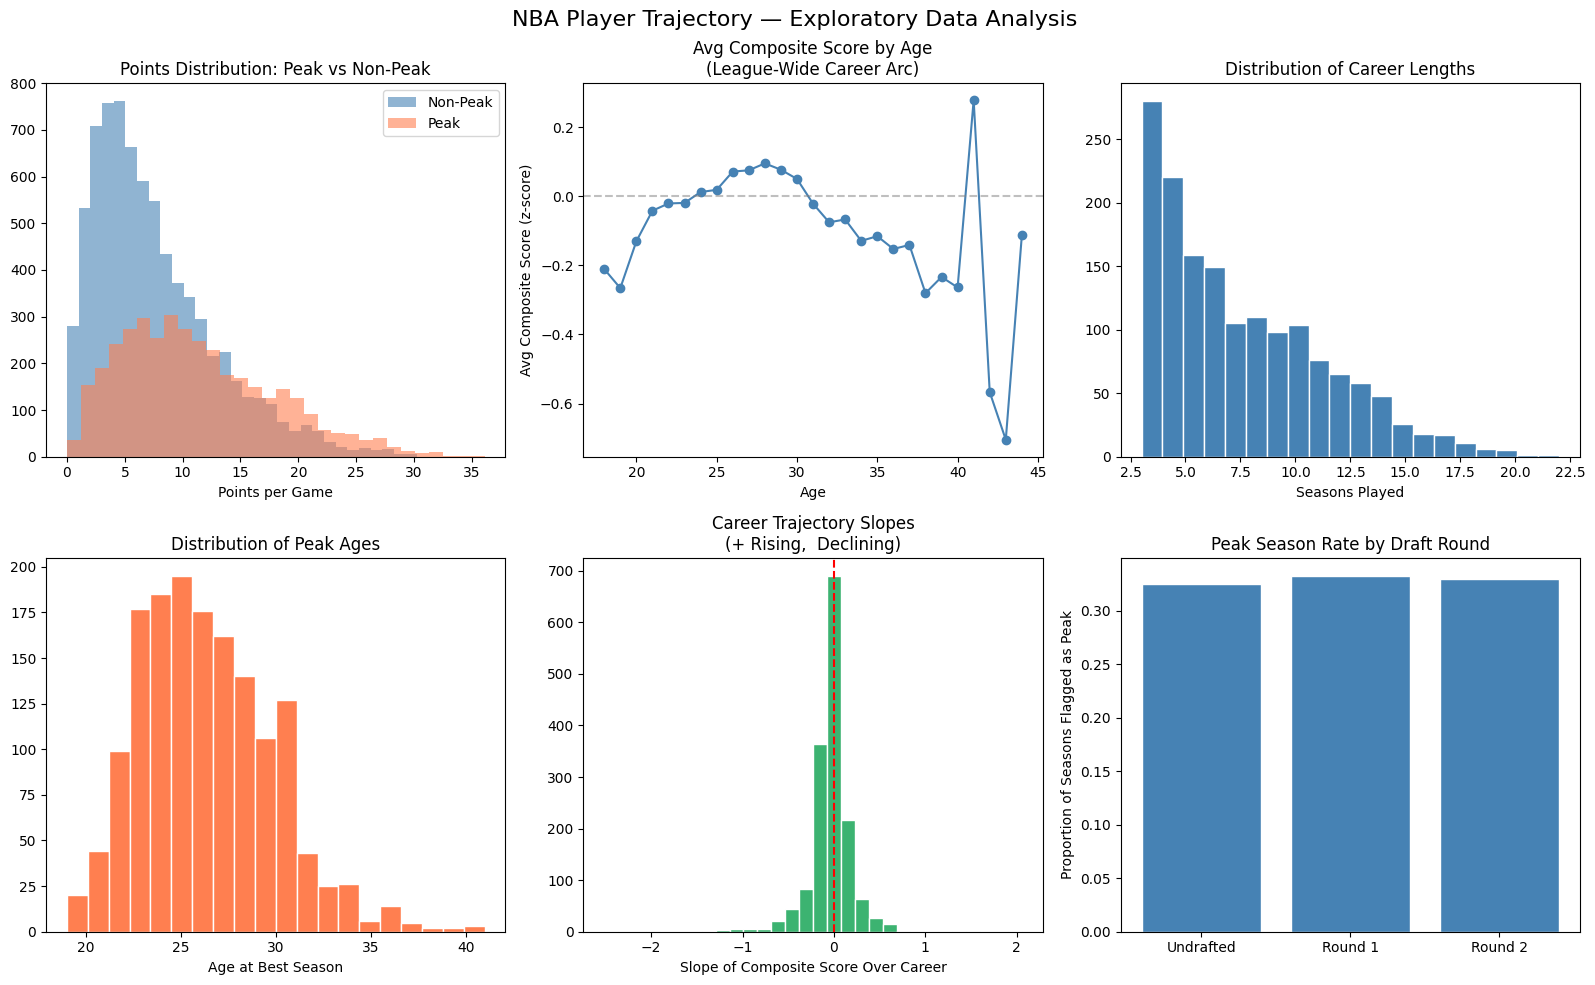

EDA plot saved: eda_plots.png


In [ ]:
# BLOCK 13 — EDA VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('NBA Player Trajectory — Exploratory Data Analysis', fontsize=16)

# Points distribution: Peak vs Non-Peak
axes[0,0].hist(df[df['is_peak']==0]['pts'], bins=30, alpha=0.6,
               label='Non-Peak', color='steelblue')
axes[0,0].hist(df[df['is_peak']==1]['pts'], bins=30, alpha=0.6,
               label='Peak', color='coral')
axes[0,0].set_title('Points Distribution: Peak vs Non-Peak')
axes[0,0].set_xlabel('Points per Game')
axes[0,0].legend()

# Avg composite score by age (the league wide career arc shape)
age_score = df.groupby('age')['composite_score'].mean().reset_index()
axes[0,1].plot(age_score['age'], age_score['composite_score'],
               marker='o', color='steelblue')
axes[0,1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0,1].set_title('Avg Composite Score by Age\n(League-Wide Career Arc)')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Avg Composite Score (z-score)')

# Career length distribution
axes[0,2].hist(player_features['career_length'], bins=20,
               color='steelblue', edgecolor='white')
axes[0,2].set_title('Distribution of Career Lengths')
axes[0,2].set_xlabel('Seasons Played')

# Peak age distribution
axes[1,0].hist(player_features['peak_age'], bins=20,
               color='coral', edgecolor='white')
axes[1,0].set_title('Distribution of Peak Ages')
axes[1,0].set_xlabel('Age at Best Season')

# Career trajectory slopes
axes[1,1].hist(player_features['score_slope'], bins=30,
               color='mediumseagreen', edgecolor='white')
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title('Career Trajectory Slopes\n(+ Rising,  Declining)')
axes[1,1].set_xlabel('Slope of Composite Score Over Career')

# Peak rate by draft round
peak_by_draft  = df.groupby('draft_round')['is_peak'].mean().reset_index()
draft_labels   = {0: 'Undrafted', 1: 'Round 1', 2: 'Round 2'}
peak_by_draft['label'] = peak_by_draft['draft_round'].map(draft_labels)
axes[1,2].bar(peak_by_draft['label'], peak_by_draft['is_peak'],
              color='steelblue', edgecolor='white')
axes[1,2].set_title('Peak Season Rate by Draft Round')
axes[1,2].set_ylabel('Proportion of Seasons Flagged as Peak')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved: eda_plots.png")

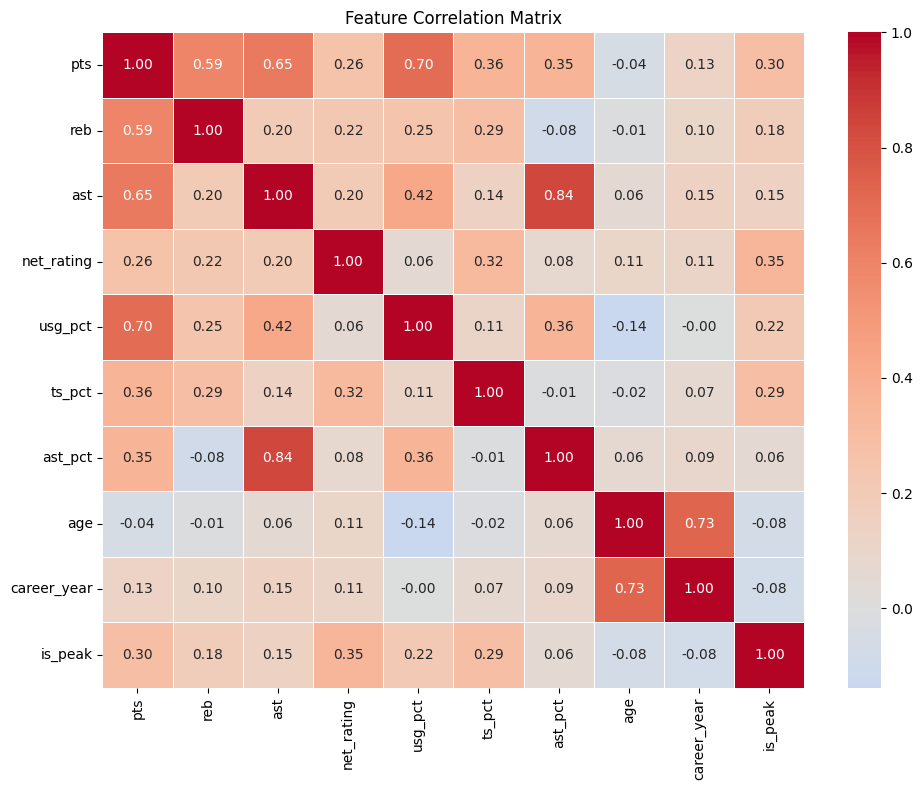

Correlation heatmap saved: correlation_heatmap.png


In [ ]:
# Correlation Heatmap

corr_cols = ['pts', 'reb', 'ast', 'net_rating', 'usg_pct',
             'ts_pct', 'ast_pct', 'age', 'career_year', 'is_peak']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved: correlation_heatmap.png")

In [ ]:
# Summary - Output for Next Steps

print("\n" + "="*60)
print("STEP 1 COMPLETE. Variables ready for Steps 2 & 3:")
print("="*60)
print(f"  df              — cleaned season-level data     {df.shape}")
print(f"  player_features — player-level trajectory vec   {player_features.shape}")
print(f"  X_cluster       — scaled features for K-Means   {X_cluster.shape}")
print(f"  X_train_scaled  — scaled train set              {X_train_scaled.shape}")
print(f"  X_test_scaled   — scaled test set               {X_test_scaled.shape}")
print(f"  y_train/y_test  — is_peak labels")
print(f"  scaler_clf      — fitted scaler (reuse Step 3)")
print("="*60)


STEP 1 COMPLETE. Variables ready for Steps 2 & 3:
  df              — cleaned season-level data     (11410, 25)
  player_features — player-level trajectory vec   (1557, 9)
  X_cluster       — scaled features for K-Means   (1557, 7)
  X_train_scaled  — scaled train set              (9129, 16)
  X_test_scaled   — scaled test set               (2281, 16)
  y_train/y_test  — is_peak labels
  scaler_clf      — fitted scaler (reuse Step 3)


In [ ]:
# K-Means Clustering — Player Archetype Discovery

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

k   | Inertia    | Silhouette
----|------------|------------
  2 |     8642.9 | 0.2072
  3 |     7679.7 | 0.1769
  4 |     7058.0 | 0.1848
  5 |     6526.5 | 0.1808
  6 |     6066.8 | 0.1682
  7 |     5712.3 | 0.1600
  8 |     5412.6 | 0.1593
  9 |     5139.7 | 0.1539
 10 |     4945.0 | 0.1576


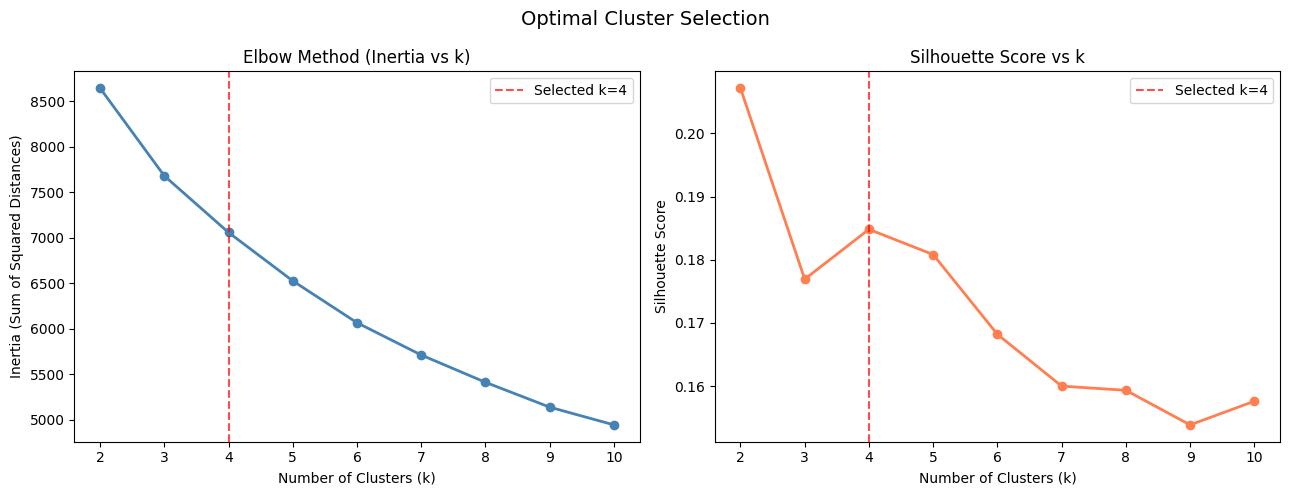

Saved: elbow_silhouette.png


In [ ]:
# Elbow Method & Silhouette Score (choose optimal k)
# We test k = 2 through 10 and record:
# inertia — sum of squared distances to cluster centers (lower = tighter)
# silhouette — how well-separated the clusters are (higher = better, max 1.0)
# The optimal k sits at the "elbow" of the inertia curve and a local peak in the silhouette score.

k_range    = range(2, 11)
inertias   = []
sil_scores = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

print("k   | Inertia    | Silhouette")
print("----|------------|------------")
for k, iner, sil in zip(k_range, inertias, sil_scores):
    print(f" {k:2d} | {iner:10.1f} | {sil:.4f}")

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimal Cluster Selection', fontsize=14)

ax1.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Selected k=4')
ax1.set_title('Elbow Method (Inertia vs k)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)')
ax1.legend()

ax2.plot(list(k_range), sil_scores, marker='o', color='coral', linewidth=2)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Selected k=4')
ax2.set_title('Silhouette Score vs k')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: elbow_silhouette.png")

In [ ]:
# Fit K-means with k=4
# k=4 is selected because:
# - The inertia curve shows a clear elbow between k=3 and k=5
# - k=4 gives a local silhouette peak (0.1848) relative to neighbors
# - 4 clusters maps naturally onto interpretable NBA player archetypes
# (validated by inspecting which players land in each cluster)

OPTIMAL_K = 4

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
player_features['cluster'] = km_final.fit_predict(X_cluster)

print(f"\nK-Means fitted with k={OPTIMAL_K}")
print("Cluster sizes:")
print(player_features['cluster'].value_counts().sort_index())

# Final silhouette score
final_sil = silhouette_score(X_cluster, player_features['cluster'])
print(f"\nFinal Silhouette Score (k={OPTIMAL_K}): {final_sil:.4f}")


K-Means fitted with k=4
Cluster sizes:
cluster
0    284
1    192
2    662
3    419
Name: count, dtype: int64

Final Silhouette Score (k=4): 0.1848


In [ ]:
# Label The Archetypes

# Labels were derived by inspecting:
#   - avg_score  (how good the player was on average)
#   - career_length (how long they played)
#   - peak_age   (when they peaked)
#   - score_slope (career trajectory direction)
#   - Representative players in each cluster
#
# Cluster 0: Short-Career Burners
#   avg_score=-0.41, career=5.1, peak_age=26, slope=-0.12
#   Solid but brief careers — peaked early, declined quickly
#   Examples: Jeremy Lin, Kendrick Nunn, Max Strus
#
# Cluster 1: Late-Peak Veterans
#   avg_score=-0.20, career=5.9, peak_age=31.3, slope=-0.15
#   Players whose best seasons came late in their careers
#   Examples: Michael Jordan (Wizards era), Karl Malone, Reggie Miller
#
# Cluster 2: Rising Stars / Young Core
#   avg_score=-0.23, career=5.7, peak_age=24, slope=+0.01
#   Young players still on upward trajectory, peaked in early 20s
#   Examples: Luka Doncic, Trae Young, Ja Morant, Zion Williamson
#
# Cluster 3: Elite Long-Tenured Stars
#   avg_score=+0.29, career=12.0, peak_age=27.9, slope=+0.01
#   The true franchise cornerstones — high performance across long careers
#   Examples: LeBron James, Kevin Durant, Stephen Curry, Joel Embiid

ARCHETYPE_LABELS = {
    0: 'Short-Career Burners',
    1: 'Late-Peak Veterans',
    2: 'Rising Stars',
    3: 'Elite Long-Tenured Stars'
}

ARCHETYPE_COLORS = {
    0: '#e07b54',   # orange
    1: '#5b8db8',   # blue
    2: '#6ab187',   # green
    3: '#9b59b6',   # purple
}

player_features['archetype'] = player_features['cluster'].map(ARCHETYPE_LABELS)

print("\nArchetype distribution:")
print(player_features['archetype'].value_counts())


Archetype distribution:
archetype
Rising Stars                662
Elite Long-Tenured Stars    419
Short-Career Burners        284
Late-Peak Veterans          192
Name: count, dtype: int64


In [ ]:
# BLOCK 4 — Archetype Summary Table

summary = player_features.groupby('archetype').agg(
    n_players    = ('player_name',    'count'),
    avg_score    = ('avg_score',      'mean'),
    peak_age     = ('peak_age',       'mean'),
    career_len   = ('career_length',  'mean'),
    slope        = ('score_slope',    'mean'),
).round(3)

print("\nArchetype Summary:")
print(summary.to_string())


Archetype Summary:
                          n_players  avg_score  peak_age  career_len  slope
archetype                                                                  
Elite Long-Tenured Stars        419      0.288    27.854      12.041  0.009
Late-Peak Veterans              192     -0.202    31.344       5.943 -0.149
Rising Stars                    662     -0.229    23.988       5.710  0.008
Short-Career Burners            284     -0.409    26.000       5.085 -0.124


In [ ]:
# Represntative Players Per Archetype

print("\nTop 8 players per archetype (by avg_score):\n")
for label in ARCHETYPE_LABELS.values():
    grp = player_features[player_features['archetype'] == label] \
              .sort_values('avg_score', ascending=False)
    print(f"--- {label} ---")
    print(grp[['player_name', 'avg_score', 'peak_age',
               'career_length', 'score_slope']].head(8).to_string(index=False))
    print()


Top 8 players per archetype (by avg_score):

--- Short-Career Burners ---
     player_name  avg_score  peak_age  career_length  score_slope
 Naz Mitrou-Long   1.201295      24.0              3    -2.513479
   Jackie Butler   1.097248      20.0              3    -1.922763
   Kendrick Nunn   0.443603      24.0              3    -0.252760
       Max Strus   0.442176      24.0              4    -0.286751
Johnathan Motley   0.429084      25.0              3     0.322930
      Jeremy Lin   0.404710      23.0              9     0.029786
   Terence Davis   0.381111      25.0              4     0.021274
  Devontae Cacok   0.332522      23.0              3    -0.430576

--- Late-Peak Veterans ---
   player_name  avg_score  peak_age  career_length  score_slope
Michael Jordan   1.565318      34.0              4    -0.433662
   Karl Malone   1.494857      33.0              8    -0.199806
David Robinson   1.040681      31.0              7    -0.194773
     Rik Smits   0.960493      31.0            

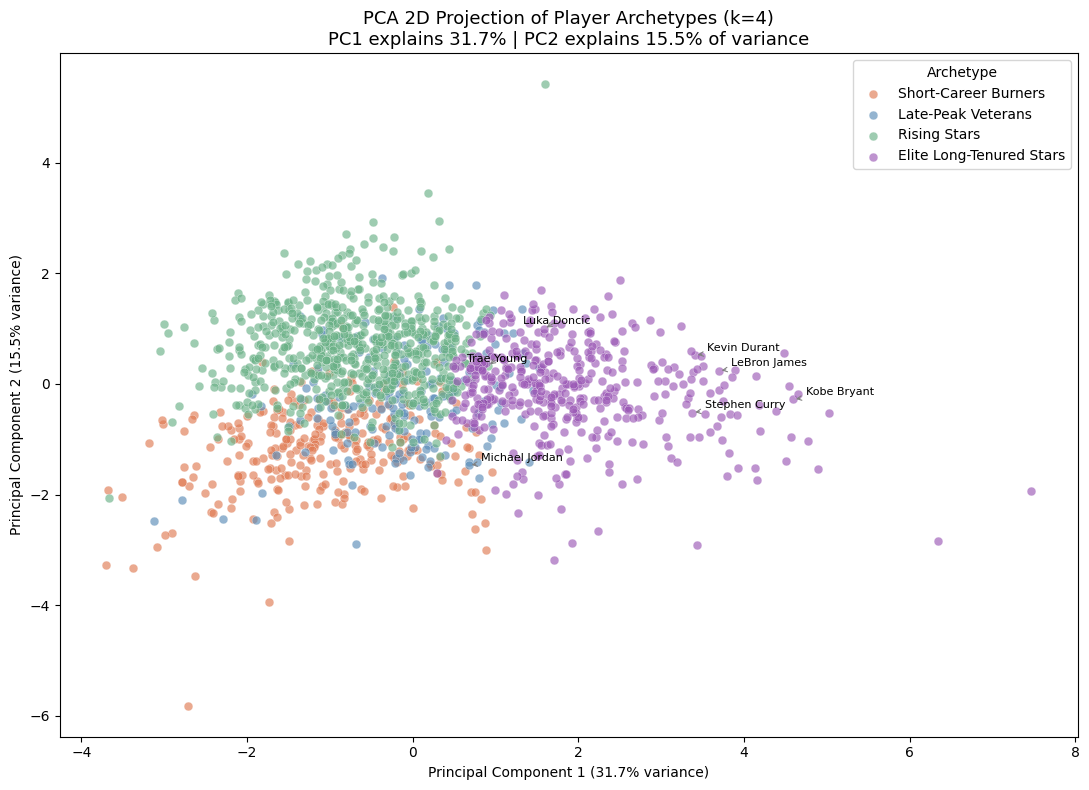

Saved: pca_clusters.png


In [ ]:
# PCA 2D Visualization of Clusters
# We reduce the 7 dimensional clustering space to 2D using PCA

pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_cluster)
var_exp  = pca.explained_variance_ratio_

player_features['pca1'] = X_pca[:, 0]
player_features['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(11, 8))

for cid, label in ARCHETYPE_LABELS.items():
    mask = player_features['cluster'] == cid
    ax.scatter(
        player_features.loc[mask, 'pca1'],
        player_features.loc[mask, 'pca2'],
        c=ARCHETYPE_COLORS[cid], label=label,
        alpha=0.65, s=40, edgecolors='white', linewidths=0.3
    )

# Few famous players
highlight = {
    'LeBron James':   (0.15, 0.08),
    'Stephen Curry':  (0.15, 0.08),
    'Kevin Durant':   (0.15, 0.08),
    'Kobe Bryant':    (0.15, 0.08),
    'Luka Doncic':   (-0.25, 0.08),
    'Trae Young':    (-0.25, 0.08),
    'Michael Jordan': (0.15, 0.08),
}

for pname, (dx, dy) in highlight.items():
    row = player_features[player_features['player_name'] == pname]
    if len(row) == 0:
        continue
    ax.annotate(
        pname,
        xy=(row['pca1'].values[0], row['pca2'].values[0]),
        xytext=(row['pca1'].values[0] + dx, row['pca2'].values[0] + dy),
        fontsize=8, color='black',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

ax.set_title(
    f'PCA 2D Projection of Player Archetypes (k=4)\n'
    f'PC1 explains {var_exp[0]:.1%} | PC2 explains {var_exp[1]:.1%} of variance',
    fontsize=13
)
ax.set_xlabel(f'Principal Component 1 ({var_exp[0]:.1%} variance)')
ax.set_ylabel(f'Principal Component 2 ({var_exp[1]:.1%} variance)')
ax.legend(title='Archetype', fontsize=10)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_clusters.png")

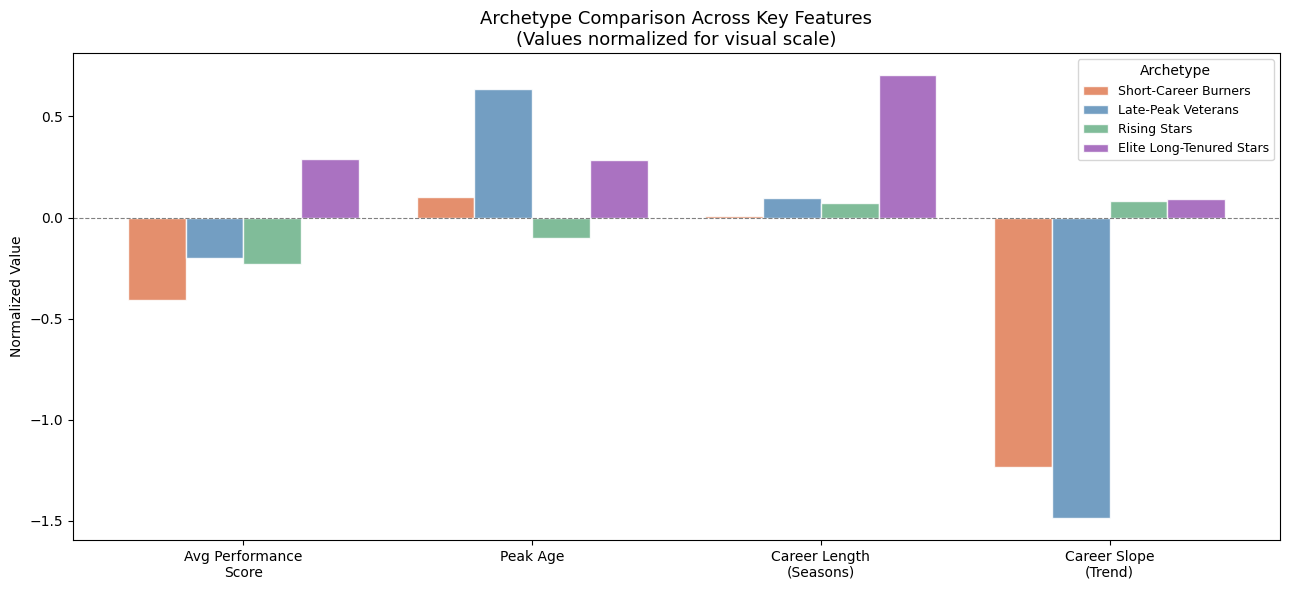

Saved: archetype_comparison.png


In [ ]:
# Cluster Feasture Radar / Bar Comparison
# Compare the 4 archetypes across key features with grouped bar charts

features_to_plot = ['avg_score', 'peak_age', 'career_length', 'score_slope']
feature_labels   = ['Avg Performance\nScore', 'Peak Age', 'Career Length\n(Seasons)', 'Career Slope\n(Trend)']

archetype_order = list(ARCHETYPE_LABELS.values())
x     = np.arange(len(features_to_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, (cid, label) in enumerate(ARCHETYPE_LABELS.items()):
    grp    = player_features[player_features['cluster'] == cid]
    # Normalize each feature to [-1,1] range for visual comparison
    vals   = [
        grp['avg_score'].mean(),
        (grp['peak_age'].mean() - 25) / 10,        # center around around 25, scale by 10
        (grp['career_length'].mean() - 5) / 10,    # center around 5, scale by 10
        grp['score_slope'].mean() * 10              # scale up small slope values
    ]
    ax.bar(x + i * width, vals, width, label=label,
           color=ARCHETYPE_COLORS[cid], edgecolor='white', alpha=0.85)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(feature_labels, fontsize=10)
ax.set_title('Archetype Comparison Across Key Features\n(Values normalized for visual scale)', fontsize=13)
ax.set_ylabel('Normalized Value')
ax.legend(title='Archetype', fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('archetype_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: archetype_comparison.png")

In [ ]:
# Merge Cluster Labels Back Into df (season-level)
# We need archetype labels on the season level dataframe

df = df.merge(
    player_features[['player_name', 'cluster', 'archetype']],
    on='player_name', how='left'
)

print(f"\ndf with cluster labels: {df.shape}")
print("Archetype column added to df:")
print(df[['player_name', 'season', 'archetype', 'is_peak']].head(10).to_string())


df with cluster labels: (11410, 27)
Archetype column added to df:
   player_name   season           archetype  is_peak
0   A.C. Green  1996-97  Late-Peak Veterans        0
1   A.C. Green  1997-98  Late-Peak Veterans        0
2   A.C. Green  1998-99  Late-Peak Veterans        0
3   A.C. Green  1999-00  Late-Peak Veterans        1
4   A.C. Green  2000-01  Late-Peak Veterans        1
5  A.J. Guyton  2000-01        Rising Stars        0
6  A.J. Guyton  2001-02        Rising Stars        1
7  A.J. Guyton  2002-03        Rising Stars        0
8     AJ Price  2009-10        Rising Stars        1
9     AJ Price  2010-11        Rising Stars        1



Peak season rate by archetype (should be highest for Elite Stars):
archetype
Elite Long-Tenured Stars    0.334
Rising Stars                0.329
Late-Peak Veterans          0.329
Short-Career Burners        0.323
Name: is_peak, dtype: float64


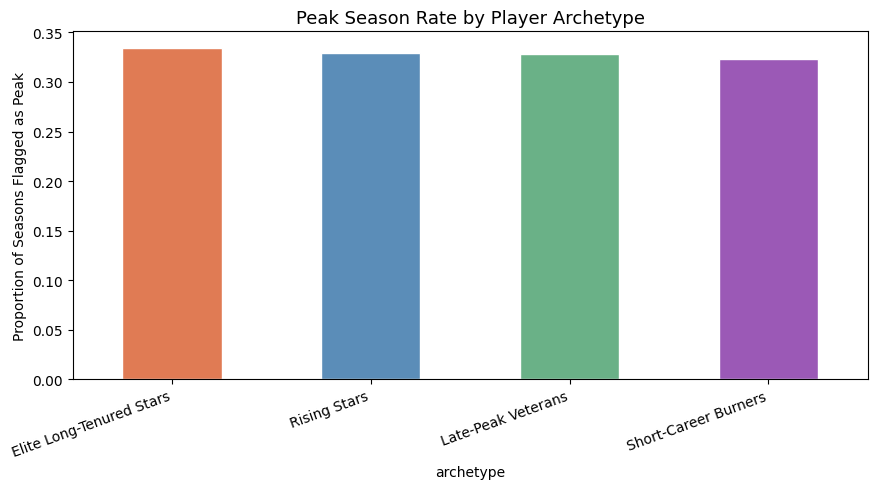

Saved: peak_rate_by_archetype.png


In [ ]:
# Peak rate by archetype
# Elite long-tenured stars should have the highest peak rate
# This validates our archetype labels are meaningful

peak_by_arch = df.groupby('archetype')['is_peak'].mean().sort_values(ascending=False)
print("\nPeak season rate by archetype (should be highest for Elite Stars):")
print(peak_by_arch.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ARCHETYPE_COLORS[k] for k, v in ARCHETYPE_LABELS.items()
          if v in peak_by_arch.index]
peak_by_arch.plot(kind='bar', ax=ax,
                  color=[ARCHETYPE_COLORS[k]
                         for k in ARCHETYPE_LABELS
                         if ARCHETYPE_LABELS[k] in peak_by_arch.index],
                  edgecolor='white')
ax.set_title('Peak Season Rate by Player Archetype', fontsize=13)
ax.set_ylabel('Proportion of Seasons Flagged as Peak')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('peak_rate_by_archetype.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: peak_rate_by_archetype.png")

In [ ]:
# SUMMARY

print("\n" + "="*60)
print("STEP 2 COMPLETE. New variables ready for Step 3:")
print("="*60)
print(f"  player_features  — now includes 'cluster' + 'archetype'  {player_features.shape}")
print(f"  df               — now includes 'cluster' + 'archetype'  {df.shape}")
print(f"  km_final         — fitted KMeans model (k=4)")
print(f"  pca              — fitted PCA model (for report figures)")
print()
print("Saved plots:")
print("  elbow_silhouette.png")
print("  pca_clusters.png")
print("  archetype_comparison.png")
print("  peak_rate_by_archetype.png")
print("="*60)


STEP 2 COMPLETE. New variables ready for Step 3:
  player_features  — now includes 'cluster' + 'archetype'  (1557, 13)
  df               — now includes 'cluster' + 'archetype'  (11410, 27)
  km_final         — fitted KMeans model (k=4)
  pca              — fitted PCA model (for report figures)

Saved plots:
  elbow_silhouette.png
  pca_clusters.png
  archetype_comparison.png
  peak_rate_by_archetype.png


In [ ]:
# Supervised Classification — Peak Season Prediction

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
!pip install xgboost -q

In [ ]:
# BLOCK 1 — TRAIN ALL THREE MODELS
# Three models chosen deliberately:
#   Logistic Regression — linear baseline; interpretable coefficients;
#                         requires scaled features (X_train_scaled)
#   Random Forest       — ensemble of decision trees; captures non-linear
#                         relationships; robust to outliers; no scaling needed
#   XGBoost             — gradient boosted trees; typically best performance;
#                         sequential error correction; no scaling needed

# ── Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# ── Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# ── XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print("All three models trained successfully.")

All three models trained successfully.


In [ ]:
# Metrics Summary Table

models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest':       (rf_pred, rf_prob),
    'XGBoost':             (xgb_pred, xgb_prob),
}

results = []
for name, (pred, prob) in models.items():
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred),   4),
        'Precision': round(precision_score(y_test, pred),  4),
        'Recall':    round(recall_score(y_test, pred),     4),
        'F1-Score':  round(f1_score(y_test, pred),         4),
        'ROC-AUC':   round(roc_auc_score(y_test, prob),    4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("\nModel Performance Summary:")
print(results_df.to_string())


Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7532     0.6632  0.5087    0.5757   0.8177
Random Forest          0.7611     0.6528  0.5859    0.6175   0.8309
XGBoost                0.7624     0.6466  0.6138    0.6298   0.8348


In [ ]:
# Classification Reports

for name, (pred, prob) in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, pred,
                                target_names=['Non-Peak (0)', 'Peak (1)']))


  Logistic Regression
              precision    recall  f1-score   support

Non-Peak (0)       0.78      0.87      0.83      1530
    Peak (1)       0.66      0.51      0.58       751

    accuracy                           0.75      2281
   macro avg       0.72      0.69      0.70      2281
weighted avg       0.74      0.75      0.74      2281


  Random Forest
              precision    recall  f1-score   support

Non-Peak (0)       0.81      0.85      0.83      1530
    Peak (1)       0.65      0.59      0.62       751

    accuracy                           0.76      2281
   macro avg       0.73      0.72      0.72      2281
weighted avg       0.76      0.76      0.76      2281


  XGBoost
              precision    recall  f1-score   support

Non-Peak (0)       0.82      0.84      0.83      1530
    Peak (1)       0.65      0.61      0.63       751

    accuracy                           0.76      2281
   macro avg       0.73      0.72      0.73      2281
weighted avg       0.76

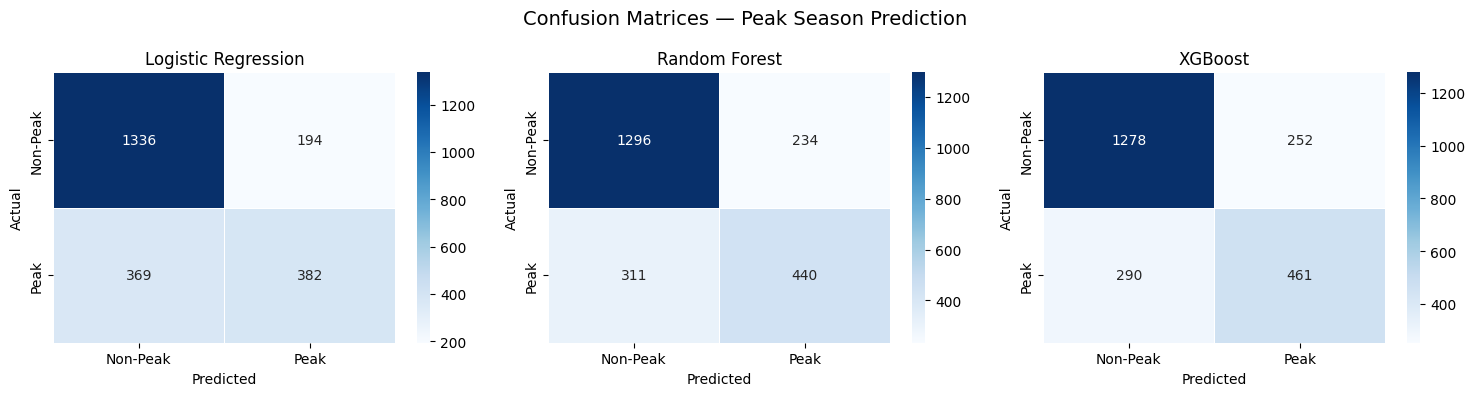

Saved: confusion_matrices.png


In [ ]:
# Confusion Matrices
=
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — Peak Season Prediction', fontsize=14)

model_names = list(models.keys())
preds       = [lr_pred, rf_pred, xgb_pred]

for ax, name, pred in zip(axes, model_names, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Peak', 'Peak'],
                yticklabels=['Non-Peak', 'Peak'],
                linewidths=0.5)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

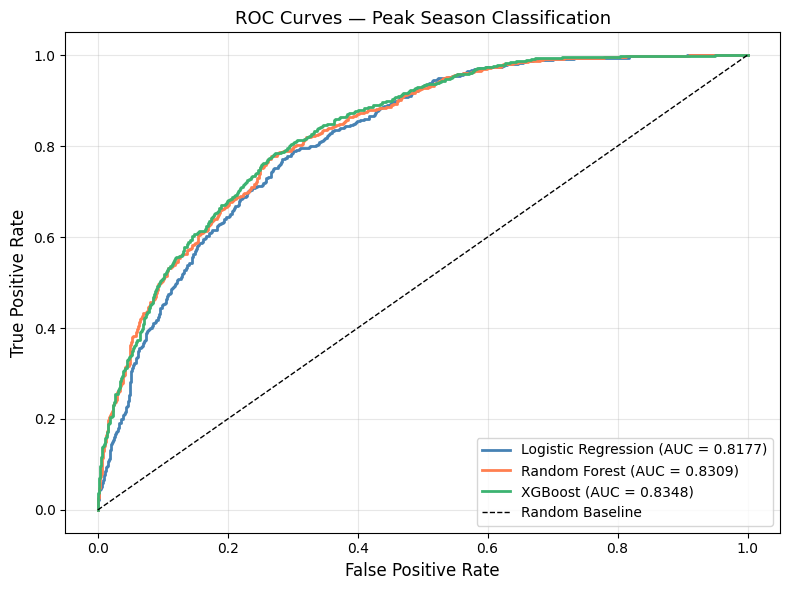

Saved: roc_curves.png


In [ ]:
# Roc Curves

fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = ['steelblue', 'coral', 'mediumseagreen']
probs_roc  = [lr_prob, rf_prob, xgb_prob]

for name, prob, color in zip(model_names, probs_roc, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc         = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Peak Season Classification', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

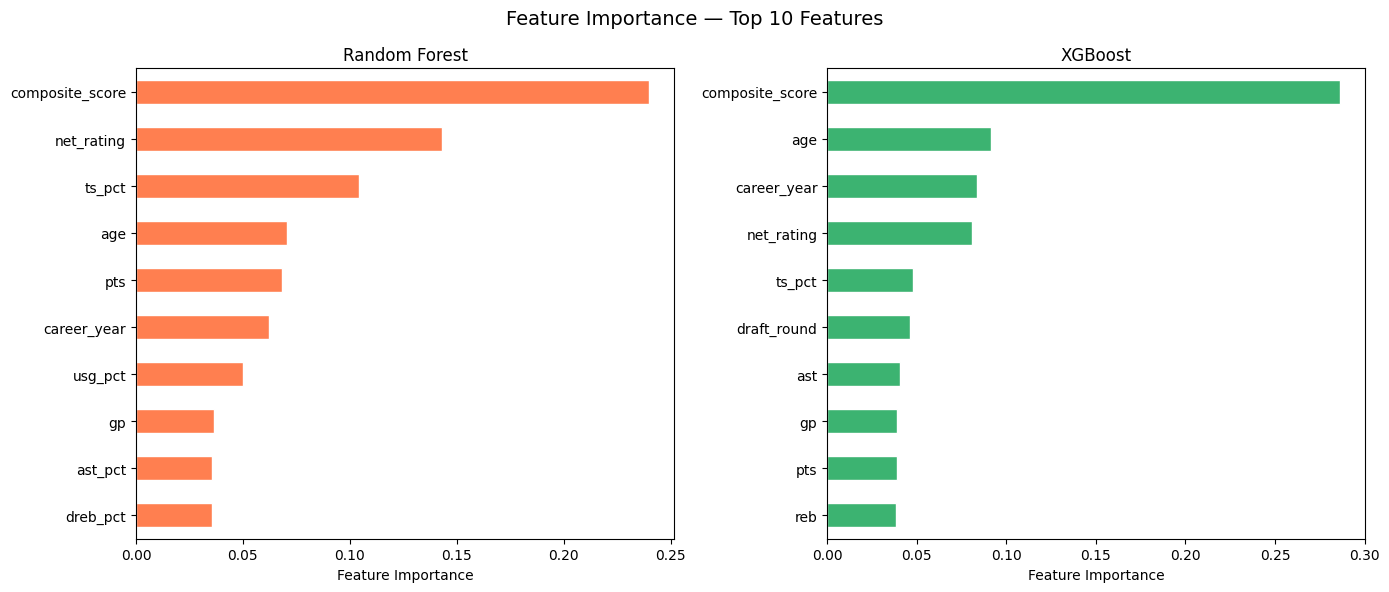

Saved: feature_importance.png

Top 10 Random Forest Feature Importances:
composite_score    0.2398
net_rating         0.1430
ts_pct             0.1045
age                0.0708
pts                0.0683
career_year        0.0620
usg_pct            0.0500
gp                 0.0366
ast_pct            0.0357
dreb_pct           0.0354

Top 10 XGBoost Feature Importances:
composite_score    0.2862
age                0.0914
career_year        0.0836
net_rating         0.0811
ts_pct             0.0477
draft_round        0.0464
ast                0.0404
gp                 0.0392
pts                0.0390
reb                0.0385


In [ ]:
# Feature Importance
# Both tree-based models provide feature importance scores.
# Showing both gives us cross-model validation of which features matter most.

fi_rf  = pd.Series(rf.feature_importances_,  index=clf_features).sort_values(ascending=False)
fi_xgb = pd.Series(xgb.feature_importances_, index=clf_features).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance — Top 10 Features', fontsize=14)

fi_rf.head(10).sort_values().plot(kind='barh', ax=ax1,
                                   color='coral', edgecolor='white')
ax1.set_title('Random Forest')
ax1.set_xlabel('Feature Importance')

fi_xgb.head(10).sort_values().plot(kind='barh', ax=ax2,
                                    color='mediumseagreen', edgecolor='white')
ax2.set_title('XGBoost')
ax2.set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

print("\nTop 10 Random Forest Feature Importances:")
print(fi_rf.head(10).round(4).to_string())
print("\nTop 10 XGBoost Feature Importances:")
print(fi_xgb.head(10).round(4).to_string())

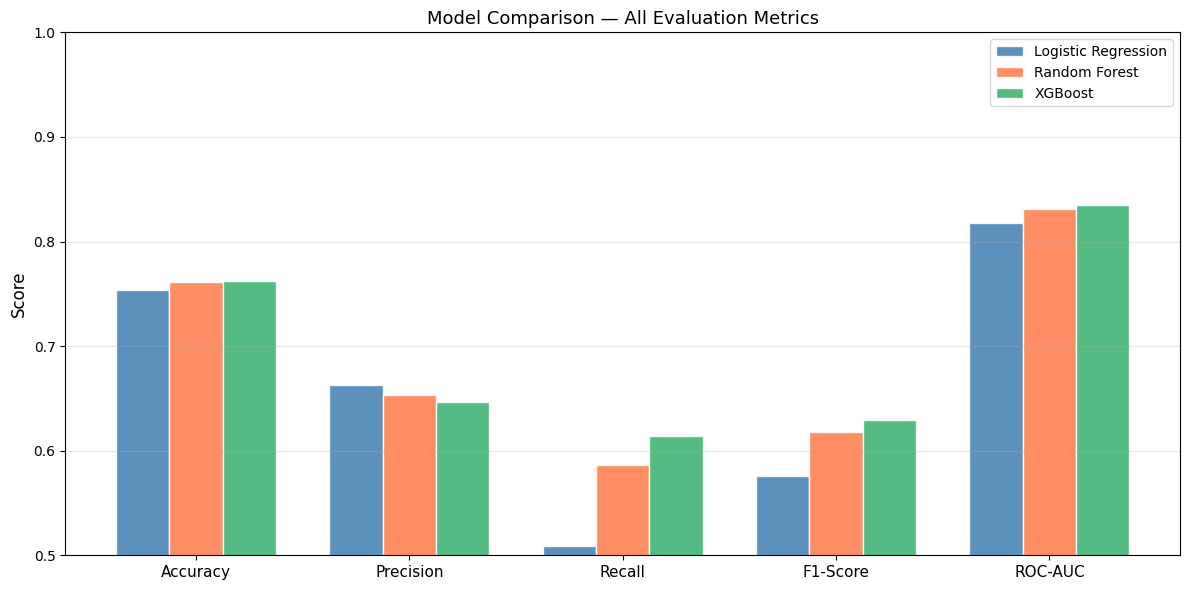

Saved: model_comparison.png


In [ ]:
# Model Comparison Bar Chart

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x         = np.arange(len(metrics))
width     = 0.25
bar_colors = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [results_df.loc[name, m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name,
           color=color, edgecolor='white', alpha=0.88)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Evaluation Metrics', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")


Championship Window Rankings — 2022-23 Season
(Teams ranked by number of players predicted in peak window)

team_abbreviation  n_players  predicted_in_peak  avg_peak_prob  avg_composite  pct_in_peak
              BOS         15                 10       0.512096       0.224733         66.7
              NYK         11                  8       0.496959       0.326078         72.7
              PHI         15                  8       0.481340       0.469560         53.3
              PHX         14                  8       0.439714       0.386689         57.1
              SAC         14                  8       0.432414       0.106501         57.1
              CLE         15                  7       0.484385       0.285324         46.7
              DEN         13                  7       0.438287       0.408298         53.8
              DAL         18                  7       0.381037       0.338282         38.9
              MEM          9                  6       0.588949       0.7

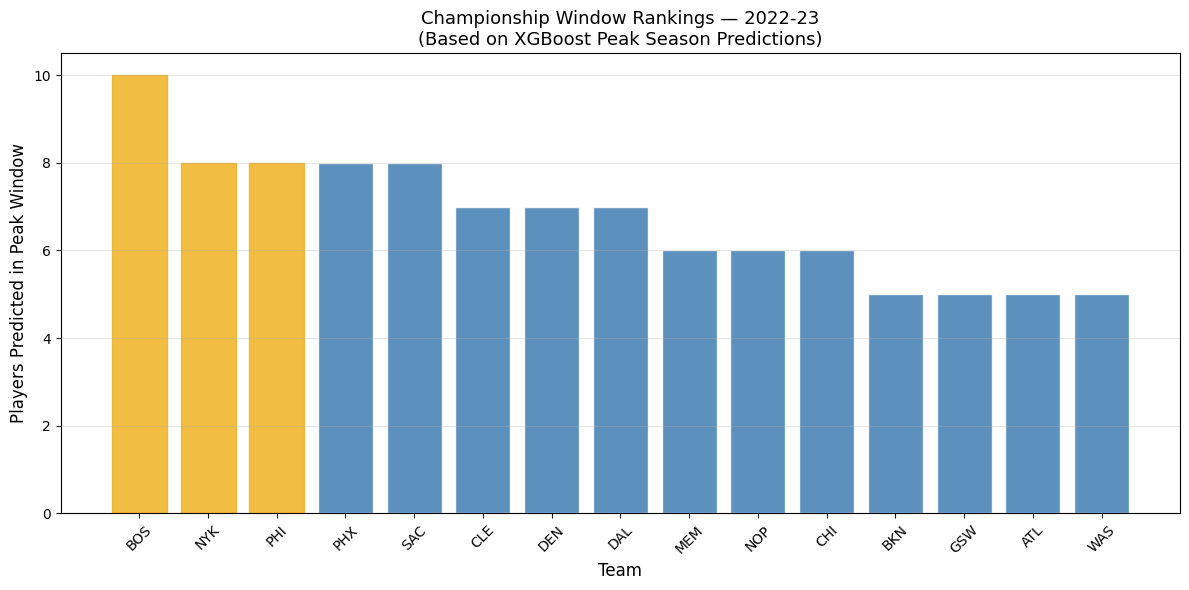

Saved: championship_window.png

Peak-window players on top 3 teams (2022-23):

--- BOS ---
        player_name  age  pts  composite_score  peak_prob                archetype
       Jayson Tatum 25.0 30.1         2.082602   0.960978 Elite Long-Tenured Stars
Robert Williams III 25.0  8.0         0.663967   0.905976             Rising Stars
      Derrick White 28.0 12.4         0.724962   0.822792             Rising Stars
       Jaylen Brown 26.0 26.6         1.706263   0.822293 Elite Long-Tenured Stars
       Mike Muscala 31.0  6.1         0.271615   0.783691 Elite Long-Tenured Stars
        Luke Kornet 27.0  3.8         0.111849   0.721232     Short-Career Burners
     Grant Williams 24.0  8.1         0.167630   0.633021             Rising Stars
    Malcolm Brogdon 30.0 14.9         0.908233   0.630599             Rising Stars
       Marcus Smart 29.0 11.5         0.356523   0.581738 Elite Long-Tenured Stars
   Payton Pritchard 25.0  5.6         0.032306   0.503806             Rising St

In [ ]:
# Championship Window Analysis
# Apply the best model (XGBoost) to the most recent season (2022-23).
# For each team, count how many of their rostered players are predicted to currently be in their peak performance window.
# Teams with the most peak window players have the best championship odds based purely on player trajectory data.

latest_season = '2022-23'
df_latest     = df[df['season'] == latest_season].copy()

# Predict peak probability for each player in 2022-23
X_latest      = df_latest[clf_features].copy()
df_latest['peak_prob']  = xgb.predict_proba(X_latest)[:, 1]
df_latest['pred_peak']  = xgb.predict(X_latest)

# Team level aggregation
team_window = (df_latest.groupby('team_abbreviation')
               .agg(
                   n_players          = ('player_name',  'count'),
                   predicted_in_peak  = ('pred_peak',    'sum'),
                   avg_peak_prob      = ('peak_prob',    'mean'),
                   avg_composite      = ('composite_score','mean'),
               )
               .reset_index()
               .sort_values('predicted_in_peak', ascending=False))

team_window['pct_in_peak'] = (team_window['predicted_in_peak'] /
                               team_window['n_players'] * 100).round(1)

print(f"\nChampionship Window Rankings — {latest_season} Season")
print("(Teams ranked by number of players predicted in peak window)\n")
print(team_window.to_string(index=False))

# Plot top 15 teams
top15 = team_window.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top15['team_abbreviation'], top15['predicted_in_peak'],
              color='steelblue', edgecolor='white', alpha=0.88)

# Color top 3 in gold
for i, bar in enumerate(bars[:3]):
    bar.set_color('#f0b429')

ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Players Predicted in Peak Window', fontsize=12)
ax.set_title(f'Championship Window Rankings — {latest_season}\n'
             f'(Based on XGBoost Peak Season Predictions)', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('championship_window.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: championship_window.png")

# Show the actual players predicted in peak for the top 3 teams
top3_teams = team_window.head(3)['team_abbreviation'].tolist()
print(f"\nPeak-window players on top 3 teams ({latest_season}):\n")
for team in top3_teams:
    players = (df_latest[(df_latest['team_abbreviation'] == team) &
                          (df_latest['pred_peak'] == 1)]
               [['player_name', 'age', 'pts', 'composite_score', 'peak_prob', 'archetype']]
               .sort_values('peak_prob', ascending=False))
    print(f"--- {team} ---")
    print(players.to_string(index=False))
    print()

In [ ]:
# Summary
print("\n" + "="*60)
print("STEP 3 COMPLETE.")
print("="*60)
print("\nModel Results:")
print(results_df.to_string())
print("\nSaved plots:")
for p in ['confusion_matrices.png', 'roc_curves.png',
          'feature_importance.png', 'model_comparison.png',
          'championship_window.png']:
    print(f"  {p}")
print("="*60)


STEP 3 COMPLETE.

Model Results:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7532     0.6632  0.5087    0.5757   0.8177
Random Forest          0.7611     0.6528  0.5859    0.6175   0.8309
XGBoost                0.7624     0.6466  0.6138    0.6298   0.8348

Saved plots:
  confusion_matrices.png
  roc_curves.png
  feature_importance.png
  model_comparison.png
  championship_window.png
